In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay)

In [ ]:
data_prediction = pd.read_excel(r"/content/predicting diabetes1.xlsx")
data_prediction.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Age,segment
0,6,148,72,35,0,33.6,50,1
1,1,85,66,29,0,26.6,31,0
2,8,183,64,0,0,23.3,32,1
3,1,89,66,23,94,28.1,21,0
4,0,137,40,35,168,43.1,33,1


In [ ]:
data_prediction.shape

(100, 8)

In [ ]:
x = data_prediction[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','Age']]
y = data_prediction["segment"]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
model = DecisionTreeClassifier()
model.fit(x_train, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
cm = confusion_matrix(y_test, y_pred)

In [ ]:
print('confusion_matrix:', cm)
print('--------------------------------------')
print('accuracy_score:', accuracy_score(y_test, y_pred))
print('--------------------------------------')
print('precision_score:', precision_score(y_test, y_pred))
print('--------------------------------------')
print('recall_score:', recall_score(y_test, y_pred))
print('--------------------------------------')
print('f1_score:', f1_score(y_test, y_pred))
print('--------------------------------------')
print('roc_auc_score:', roc_auc_score(y_test, y_pred))
print('--------------------------------------')
print('classification_report:','\n',classification_report(y_test, y_pred))

confusion_matrix: [[8 5]
 [3 4]]
--------------------------------------
accuracy_score: 0.6
--------------------------------------
precision_score: 0.4444444444444444
--------------------------------------
recall_score: 0.5714285714285714
--------------------------------------
f1_score: 0.5
--------------------------------------
roc_auc_score: 0.5934065934065934
--------------------------------------
classification_report: 
               precision    recall  f1-score   support

           0       0.73      0.62      0.67        13
           1       0.44      0.57      0.50         7

    accuracy                           0.60        20
   macro avg       0.59      0.59      0.58        20
weighted avg       0.63      0.60      0.61        20



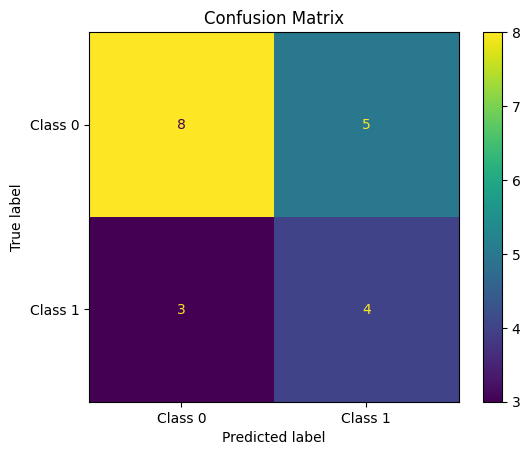

In [ ]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Class 0", "Class 1"]
)

disp.plot()

plt.title("Confusion Matrix")
plt.show()


In [ ]:
comparison = pd.DataFrame({
    'Actual': y_test.values.ravel(),
    'Predicted': y_pred.ravel()
})

display(comparison)

,Actual,Predicted
0,0,1
1,1,0
2,0,1
3,1,0
4,0,1
5,1,1
6,1,1
7,0,0
8,0,0
9,1,1



ROC-AUC: 0.5934065934065934


Text(0.5, 1.0, 'ROC Curve')

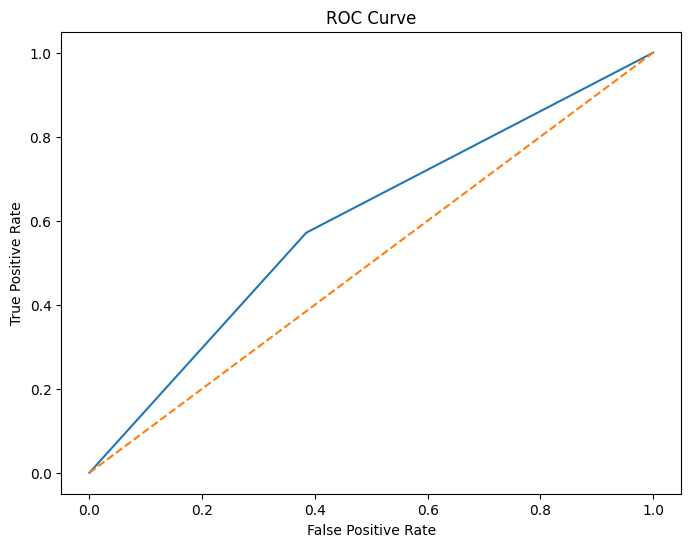

In [ ]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred
)

auc_score = roc_auc_score(
    y_test,
    y_pred
)

print("\nROC-AUC:", auc_score)


# Plot ROC Curve

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")